In [ ]:
!pip install google-api-python-client nltk

In [ ]:
from google.colab import userdata
API_KEY = userdata.get('YOUTUBE_API_KEY')

In [ ]:
# 1. Install necessary libraries
!pip install google-api-python-client nltk

# 2. Imports
import pandas as pd
import sqlite3
import re
import nltk
from googleapiclient.discovery import build
from google.colab import userdata
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 3. Setup credentials and service
nltk.download('vader_lexicon', quiet=True)


print("SUCCESS: 'build' is now defined and the YouTube service is ready.")

SUCCESS: 'build' is now defined and the YouTube service is ready.


In [ ]:
VIDEO_ID = 'eHTXQW58WhA'
youtube = build('youtube', 'v3', developerKey=API_KEY)

# 2. FETCH COMMENTS
def get_comments(video_id):
    comments = []
    request = youtube.commentThreads().list(part="snippet", videoId=video_id, maxResults=100)
    while request:
        response = request.execute()
        for item in response['items']:
            c = item['snippet']['topLevelComment']['snippet']
            comments.append({
                'text': re.sub(r'http\S+', '', c['textDisplay']), # Remove URLs
                'author': c['authorDisplayName'],
                'likes': c['likeCount']
            })
        request = youtube.commentThreads().list_next(request, response) if 'nextPageToken' in response else None
    return pd.DataFrame(comments)

# 3. ANALYZE SENTIMENT
def analyze_sentiment(df):
    sia = SentimentIntensityAnalyzer()
    df['score'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
    df['sentiment'] = df['score'].apply(lambda c: 'Positive' if c >= 0.05 else ('Negative' if c <= -0.05 else 'Neutral'))
    return df

# 4. EXECUTE & STORE
df = get_comments(VIDEO_ID)
df = analyze_sentiment(df)

conn = sqlite3.connect('latent_analysis.db')
df.to_sql('comments', conn, if_exists='replace', index=False)
conn.close()

print(f"Success! Processed {len(df)} comments and saved to SQLite.")
print(df.head())

Success! Processed 89989 comments and saved to SQLite.
                                                text                author  \
0                        Yaar kitni pyaari hai aliya      @fardeenkhan5270   
1                                Next episode please  @venkateshtupaki5980   
2  Alia be like &quot; sirf mujhe kyu toda &quot;😆😆😆             @na_p7597   
3                                <a href=" asli maza            @BOTOtuber   
4                           Reference for @<a href="     @rishabhyadav2476   

   likes   score sentiment  
0      0  0.0000   Neutral  
1      0  0.3182  Positive  
2      1  0.3612  Positive  
3      0  0.0000   Neutral  
4      0  0.0000   Neutral  


In [ ]:
df.head(10)

,text,author,likes,score,sentiment
0,Yaar kitni pyaari hai aliya,@fardeenkhan5270,0,0.0000,Neutral
1,Next episode please,@venkateshtupaki5980,0,0.3182,Positive
2,Alia be like &quot; sirf mujhe kyu toda &quot;😆😆😆,@na_p7597,1,0.3612,Positive
3,"<a href="" asli maza",@BOTOtuber,0,0.0000,Neutral
4,"Reference for @<a href=""",@rishabhyadav2476,0,0.0000,Neutral
5,Bhai show ki ticket kaha se milti hai,@shubhamver,0,0.0000,Neutral
6,Samay... Just play Chesssss... That is classes...,@HisSlaveByChoice,0,0.3400,Positive
7,Sukrudev&#39;s aura after that &quot;cut&quot;💯💯💯,@Merina-y4j,0,0.0000,Neutral
8,Surkrudev ka acting next level ka tha 💯❣️,@Merina-y4j,5,0.0000,Neutral
9,yuooottttttttttttttttt<br>j08uhklfbohi0ggdhi8d...,@MdMohtasim-z4l,0,0.0000,Neutral


In [ ]:
df['text'].head()

,text
0,Yaar kitni pyaari hai aliya
1,Next episode please
2,Alia be like &quot; sirf mujhe kyu toda &quot;😆😆😆
3,"<a href="" asli maza"
4,"Reference for @<a href="""


In [ ]:
# Grouping sentiment distribution
sentiment_summary = df['sentiment'].value_counts(normalize=True) * 100
print("Sentiment Breakdown (%):\n", sentiment_summary.round(2))

# Extracting the top 5 most-liked comments to gauge audience consensus
top_liked = df.nlargest(5, 'likes')[['text', 'likes', 'sentiment']]
display(top_liked)

Sentiment Breakdown (%):
 sentiment
Neutral     58.85
Positive    30.81
Negative    10.33
Name: proportion, dtype: float64


,text,likes,sentiment
76051,Mai police ki taraf se hi aaya tha.,237224,Neutral
43197,Bring That Trump In the Panel😭💀,76550,Neutral
78628,That Drunk guy lowkey gave me goosebumps when ...,72326,Negative
44492,"The people who have watched 1st season, know h...",66632,Positive
55107,First ever hit show jiska channel pe season 1 ...,55264,Neutral


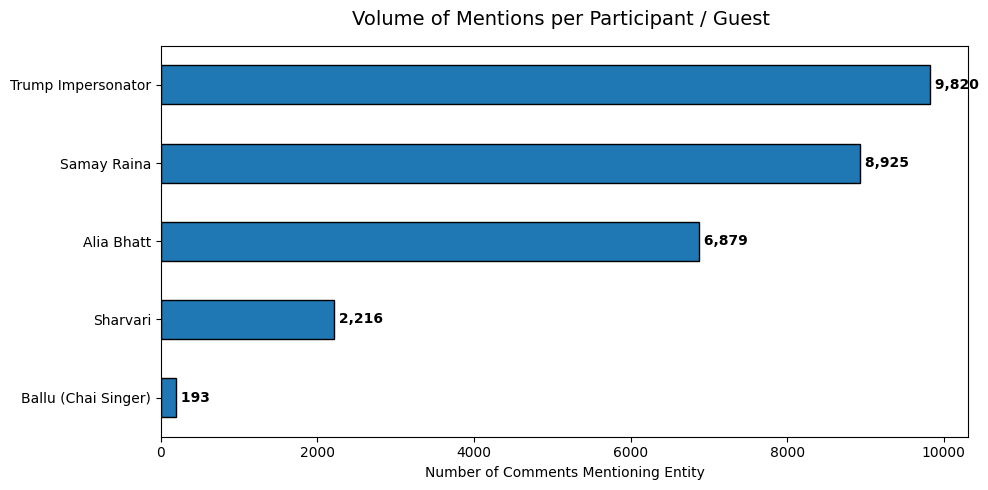

In [ ]:
import matplotlib.pyplot as plt

tracking_dict = {
    'Trump Impersonator': r'(?i)\b(?:trump|donald|mimic)\b',
    'Alia Bhatt':         r'(?i)\b(?:alia|bhatt)\b',
    'Ballu (Chai Singer)': r'(?i)\b(?:ballu|chai|tapri)\b',
    'Sharvari':           r'(?i)\bsharvari\b',
    'Samay Raina':        r'(?i)\b(?:samay|raina)\b',
}

# Count mentions
mention_counts = {
    person: df['text'].str.contains(pattern, na=False).sum()
    for person, pattern in tracking_dict.items()
}

mentions = pd.Series(mention_counts).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 5))
mentions.plot(kind='barh', edgecolor='black')

plt.title("Volume of Mentions per Participant / Guest ", fontsize=14, pad=15)
plt.xlabel("Number of Comments Mentioning Entity")

# Value labels
for i, v in enumerate(mentions):
    plt.text(v, i, f" {v:,}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

# 3. Top 15 Most Common Words
print("3. Top 15 Most Common Words:")

text = ' '.join(df['text'].dropna()).lower()
words = [word for word in text.split() if len(word) > 3]

top_words = Counter(words).most_common(15)

for word, count in top_words:
    print(f"{word:<15} → {count:,} times")

3. Top 15 Most Common Words:
bhai            → 10,061 times
samay           → 8,538 times
trump           → 8,508 times
href="          → 8,092 times
show            → 6,284 times
alia            → 6,276 times
this            → 5,966 times
donald          → 4,499 times
episode         → 4,322 times
that            → 3,641 times
love            → 3,070 times
like            → 2,792 times
good            → 2,674 times
season          → 2,428 times
back            → 2,373 times


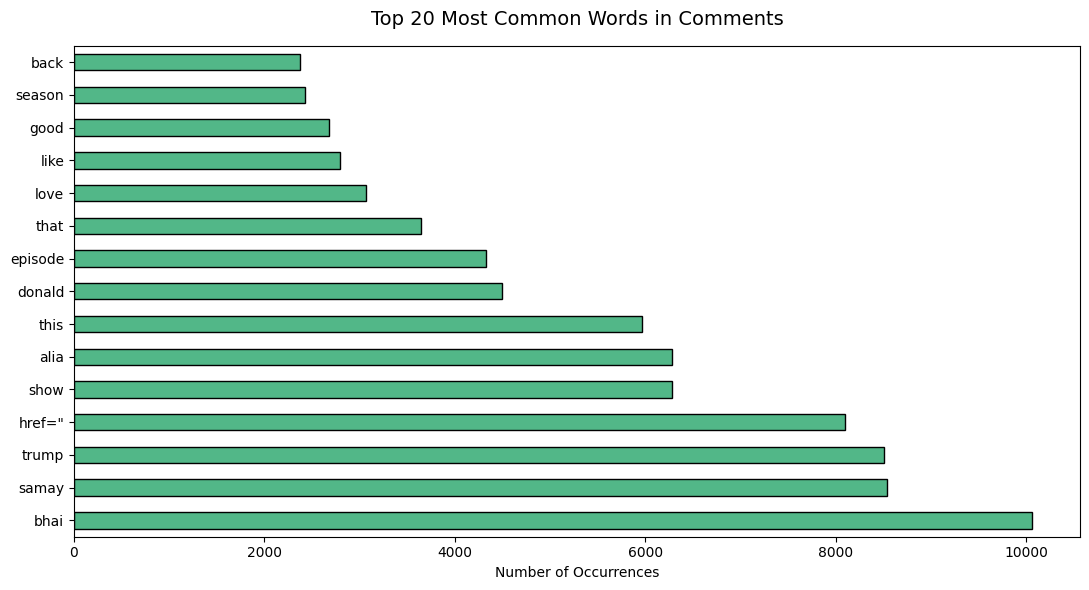

In [ ]:

top_words_series = pd.Series(dict(top_words))

plt.figure(figsize=(11, 6))
top_words_series.plot(kind='barh', edgecolor='black', color='#52b788')

plt.title("Top 20 Most Common Words in Comments", fontsize=14, pad=15)
plt.xlabel("Number of Occurrences")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

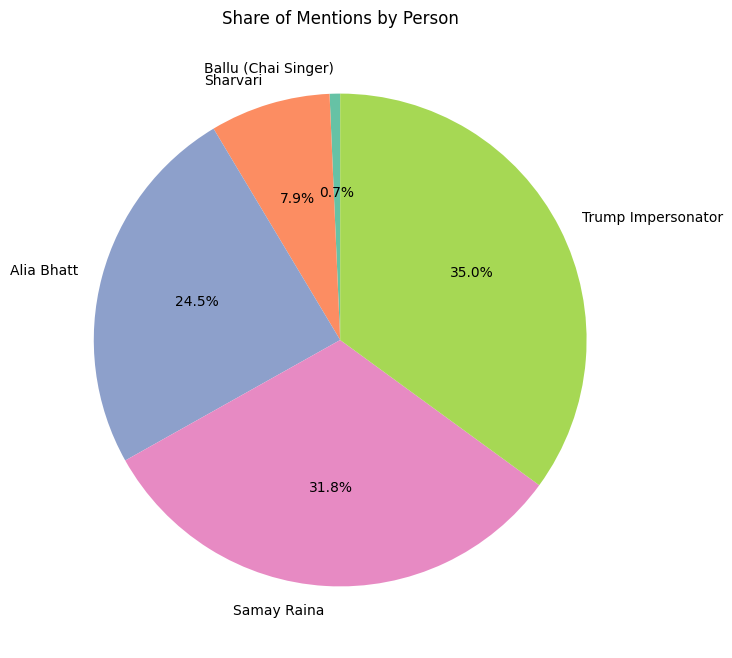

In [ ]:
plt.figure(figsize=(8, 8))
mentions.plot(kind='pie', autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette("Set2"))
plt.title("Share of Mentions by Person")
plt.ylabel("")
plt.show()

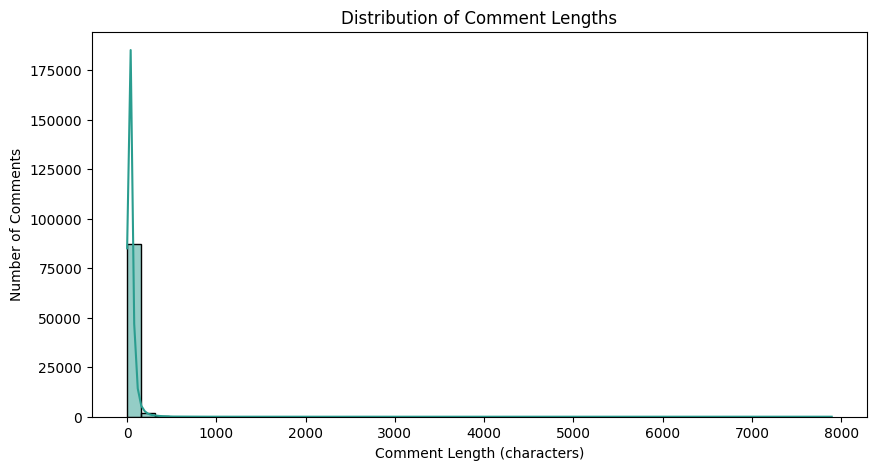

In [ ]:
df['comment_length'] = df['text'].str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df['comment_length'], bins=50, kde=True, color='#2a9d8f')
plt.title("Distribution of Comment Lengths")
plt.xlabel("Comment Length (characters)")
plt.ylabel("Number of Comments")
plt.show()

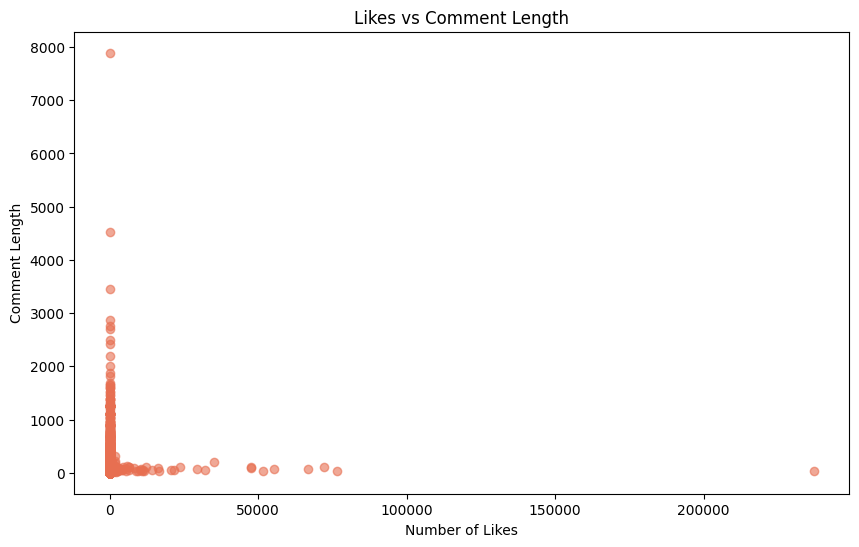

In [ ]:
if 'likes' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['likes'], df['text'].str.len(), alpha=0.6, color='#e76f51')
    plt.title("Likes vs Comment Length")
    plt.xlabel("Number of Likes")
    plt.ylabel("Comment Length")
    plt.show()